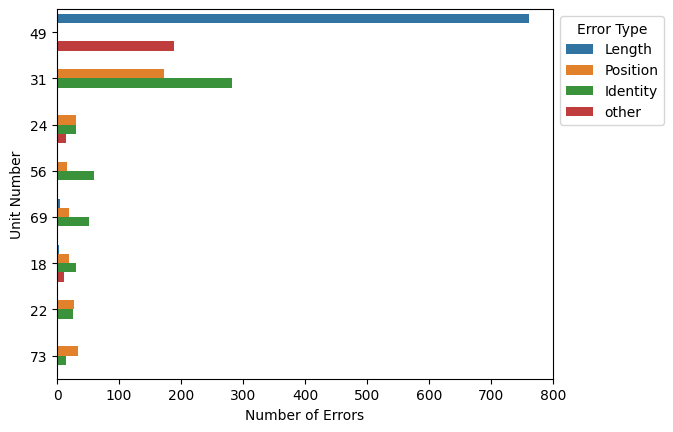

In [ ]:
import os
import sys

current = os.path.abspath("")
parent = os.path.dirname(current)
sys.path.append(parent)

from collections import Counter
import pandas as pd
from ast import literal_eval
import pathlib
import seaborn as sns
from swp.utils.datasets import enrich_for_plotting

converters = {
    "Word" : str,
    "Phonemes" : literal_eval,
    "No_Stress" : literal_eval,
    "Prediction" : literal_eval,
}

def is_early_eos(pred, gt):
    for i in range(len(pred)):
        if pred[i]=="<EOS>":
            return True
        elif pred[i]!=gt[i]:
            return False
    return False

def is_position_error(pred, gt):
    gt_count = Counter(pred)
    pred_count = Counter(gt)
    delta = len(list((gt_count-pred_count).keys())) + len(list((pred_count-gt_count).keys()))
    return delta==0

def is_identity_error(pred, gt):
    for i in range(len(pred)):
        if pred[i] in {"<EOS>", "<SOS>", "<PAD>"}:
            return False
    return True

ablations = pathlib.Path(current) / "ablations"
df_dict={"Unit Number" : [], "Error Type" : [], "Rate" : [], "Number of Errors" : [], "Unit Name" : []}
err_dict = {}
for neuron_type in ["encoder", "decoder"]:
    for i in range(128):
        neuron = f"{neuron_type}_{i}"
        df = pd.read_csv(ablations / f"{neuron}.csv", index_col = 0, converters = converters)
        df = enrich_for_plotting(df, False)
        df["Error_Rate"] = (df["Edit_Distance"] > 0).astype(int)
        errors = df["Error_Rate"].sum()
        err_dict[neuron]=errors
        if errors >= 50:
            eos = 0
            permute = 0
            identity = 0
            other = 0

            for (index, row) in df.iterrows():
                pred = row["Prediction"]
                gt = row["No_Stress"]
                is_other = True

                if row["Error_Rate"]==1:
                    if is_early_eos(pred, gt):
                        eos +=1
                        is_other=False
                    if is_position_error(pred, gt):
                        permute+=1
                        is_other=False
                    elif is_identity_error(pred, gt):
                        identity+=1
                        is_other=False
                    if is_other:
                        other+=1
            for errtype, errcount in [
                ("Length", eos),
                ("Position", permute),
                ("Identity", identity),
                ("other", other)
                ]:
                df_dict["Unit Number"].append(str(i))
                df_dict["Error Type"].append(errtype)
                df_dict["Number of Errors"].append(errcount)
                df_dict["Rate"].append(round(errcount/errors*100))
                df_dict["Unit Name"].append(neuron)
error_df = pd.DataFrame(df_dict)

error_df = error_df.iloc[sorted(error_df.index, key=lambda k: err_dict[error_df.loc[k, "Unit Name"]], reverse=True)]

import seaborn as sns

ax = sns.barplot(error_df, y = "Unit Number", x = "Number of Errors", hue = "Error Type", orient = "h")#, dodge=False)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))